# Chapter 7: Determinants

**Book:** *Linear Algebra with Applications in Machine Learning: From Intuitive Understanding to Python Coding*

---

The determinant is a single scalar that encodes whether a matrix is invertible, how it scales volume, and whether it flips orientation. This notebook covers:

1. **Definition and Basics** — 2x2 and 3x3 determinants, geometric interpretation as area/volume
2. **Computing Determinants** — cofactor expansion, upper triangular shortcut
3. **Properties** — row operations, scalar mult, products, transpose, inverse, powers
4. **Cramer's Rule** — solving systems via determinant ratios
5. **Determinants in ML** — regression invertibility, covariance, normalizing flows

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 12
np.set_printoptions(precision=4, suppress=True)

print("All imports successful.")

All imports successful.


## 7.1 Determinants: Definition and Basics

The **determinant** of a square matrix $A$, written $\det(A)$ or $|A|$, is a scalar that tells us three things at once:

- **Invertibility:** $A$ is invertible if and only if $\det(A) \neq 0$
- **Volume scaling:** $|\det(A)|$ is the factor by which $A$ scales areas (2D) or volumes (3D)
- **Orientation:** $\det(A) > 0$ preserves orientation; $\det(A) < 0$ reverses it

### 2x2 Determinant

$$\det\begin{bmatrix} a & b \\ c & d \end{bmatrix} = ad - bc$$

Geometrically, $|\det(A)|$ is the area of the parallelogram formed by the column vectors.

In [2]:
A = np.array([[1, 2],
              [3, 4]])

det_A = np.linalg.det(A)
print(f"A =\n{A}")
print(f"det(A) = {det_A:.2f}")
print(f"|det(A)| = {abs(det_A):.2f}  (parallelogram area)")
print(f"Sign: {'preserves' if det_A > 0 else 'reverses'} orientation")
print(f"Invertible: {abs(det_A) > 1e-10}")

A =
[[1 2]
 [3 4]]
det(A) = -2.00
|det(A)| = 2.00  (parallelogram area)
Sign: reverses orientation
Invertible: True


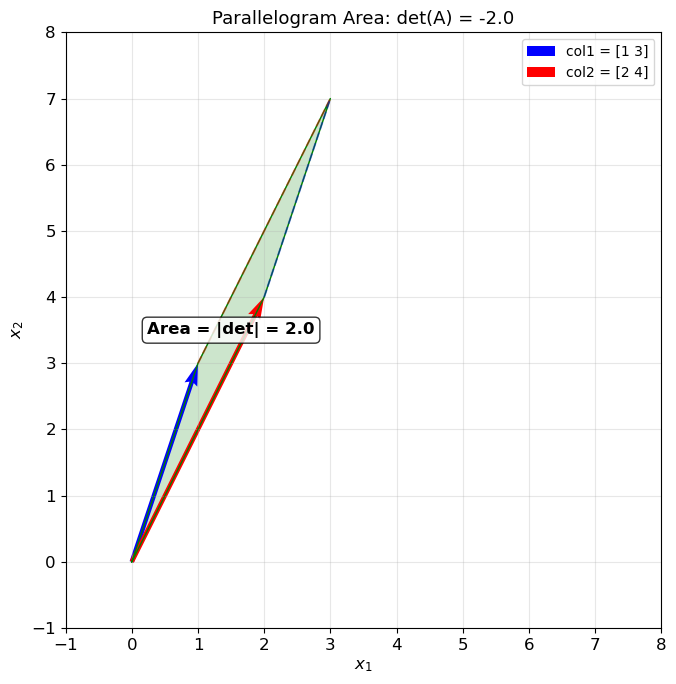

In [3]:
def plot_parallelogram(A, title=''):
    """Visualize the parallelogram formed by columns of a 2x2 matrix."""
    v1, v2 = A[:, 0], A[:, 1]
    det_val = np.linalg.det(A)
    
    fig, ax = plt.subplots(figsize=(7, 7))
    
    # Parallelogram
    corners = np.array([[0,0], v1, v1+v2, v2, [0,0]])
    ax.fill(corners[:, 0], corners[:, 1], alpha=0.2, color='green')
    ax.plot(corners[:, 0], corners[:, 1], 'g-', linewidth=1)
    
    # Column vectors
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
              color='blue', linewidth=2.5, label=f'col1 = {v1}')
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
              color='red', linewidth=2.5, label=f'col2 = {v2}')
    # Dashed completions
    ax.plot([v1[0], v1[0]+v2[0]], [v1[1], v1[1]+v2[1]], 'r--', alpha=0.4)
    ax.plot([v2[0], v1[0]+v2[0]], [v2[1], v1[1]+v2[1]], 'b--', alpha=0.4)
    
    ax.text((v1[0]+v2[0])/2, (v1[1]+v2[1])/2,
            f'Area = |det| = {abs(det_val):.1f}', fontsize=12,
            ha='center', va='center', fontweight='bold',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    
    lim = max(abs(v1).max(), abs(v2).max(), abs(v1+v2).max()) + 1
    ax.set_xlim(-1, lim)
    ax.set_ylim(-1, lim)
    ax.set_aspect('equal')
    ax.set_xlabel(r'$x_1$')
    ax.set_ylabel(r'$x_2$')
    ax.set_title(f'{title}det(A) = {det_val:.1f}', fontsize=13)
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_parallelogram(np.array([[1,2],[3,4]]), 'Parallelogram Area: ')

det(B) = 8


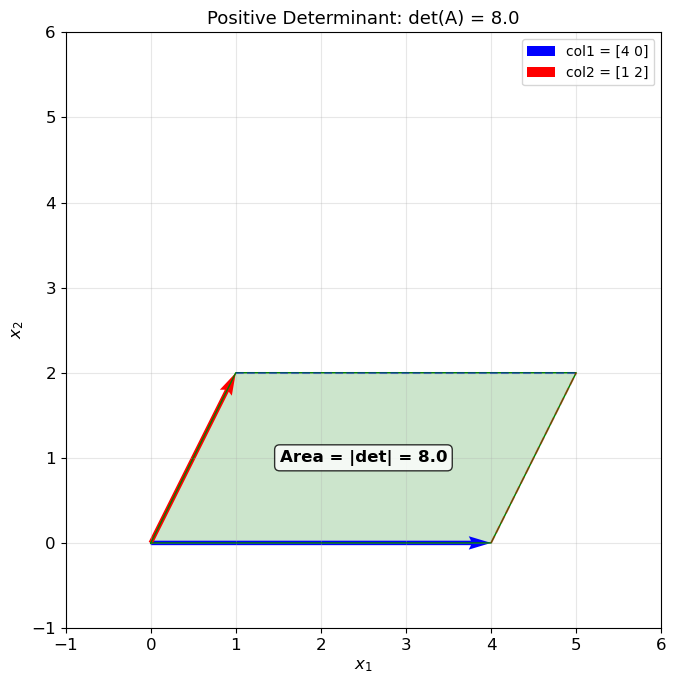

In [4]:
# Another example: det = 8 (positive, preserves orientation)
B = np.array([[4, 1],
              [0, 2]])
print(f"det(B) = {np.linalg.det(B):.0f}")
plot_parallelogram(B, 'Positive Determinant: ')

### Singular Matrix: det = 0

When columns are linearly dependent, the parallelogram collapses to a line and the area is zero.

In [5]:
C = np.array([[1, 2],
              [2, 4]])  # col2 = 2 * col1

print(f"C =\n{C}")
print(f"det(C) = {np.linalg.det(C):.4f}  (zero => singular, not invertible)")
print(f"Column 2 = 2 * Column 1 => linearly dependent => area collapses to 0")

C =
[[1 2]
 [2 4]]
det(C) = 0.0000  (zero => singular, not invertible)
Column 2 = 2 * Column 1 => linearly dependent => area collapses to 0


### 3x3 Determinant: Volume of a Parallelepiped

For a $3 \times 3$ matrix, the determinant is the signed volume of the parallelepiped spanned by its three column vectors. It can be computed via **cofactor expansion** along any row or column:

$$\det(A) = a_{11}(a_{22}a_{33} - a_{23}a_{32}) - a_{12}(a_{21}a_{33} - a_{23}a_{31}) + a_{13}(a_{21}a_{32} - a_{22}a_{31})$$

In [6]:
A3 = np.array([[1, 2, 3],
               [4, 5, 6],
               [7, 8, 0]])

det_A3 = np.linalg.det(A3)
print(f"A =\n{A3}")
print(f"det(A) = {det_A3:.2f}")

# Manual cofactor expansion along row 1
manual = (1*(5*0 - 6*8) - 2*(4*0 - 6*7) + 3*(4*8 - 5*7))
print(f"Manual cofactor expansion: {manual}")
print(f"Match: {np.isclose(det_A3, manual)}")

A =
[[1 2 3]
 [4 5 6]
 [7 8 0]]
det(A) = 27.00
Manual cofactor expansion: 27
Match: True


In [7]:
# SymPy for exact cofactor expansion
M = sp.Matrix([[1, 2, 1],
               [0, 3, 4],
               [3, 1, 4]])

print("A =")
sp.pprint(M)
print(f"\ndet(A) = {M.det()}")

# Show cofactors along row 1
print("\nCofactor expansion along row 1:")
for j in range(3):
    minor = M.minor_submatrix(0, j)
    cof = (-1)**(0+j) * sp.Matrix(minor).det()
    print(f"  a_1{j+1}={M[0,j]}, cofactor C_1{j+1} = {cof}, contribution = {M[0,j] * cof}")
print(f"  Sum = {M.det()}")

A =
⎡1  2  1⎤
⎢       ⎥
⎢0  3  4⎥
⎢       ⎥
⎣3  1  4⎦

det(A) = 23

Cofactor expansion along row 1:
  a_11=1, cofactor C_11 = 8, contribution = 8
  a_12=2, cofactor C_12 = 12, contribution = 24
  a_13=1, cofactor C_13 = -9, contribution = -9
  Sum = 23


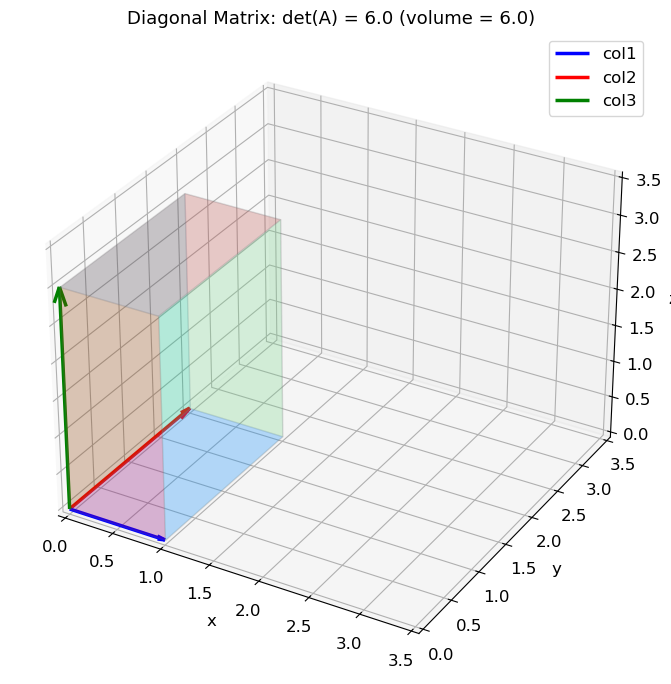

In [8]:
# Visualize 3D parallelepiped
def plot_parallelepiped(A, title=''):
    """Visualize the parallelepiped formed by columns of a 3x3 matrix."""
    v1, v2, v3 = A[:, 0], A[:, 1], A[:, 2]
    det_val = np.linalg.det(A)
    
    # 8 vertices of the parallelepiped
    o = np.zeros(3)
    vertices = [o, v1, v2, v3, v1+v2, v1+v3, v2+v3, v1+v2+v3]
    
    # 6 faces
    faces = [
        [o, v1, v1+v2, v2],
        [o, v1, v1+v3, v3],
        [o, v2, v2+v3, v3],
        [v1+v2+v3, v1+v2, v1, v1+v3],
        [v1+v2+v3, v1+v2, v2, v2+v3],
        [v1+v2+v3, v1+v3, v3, v2+v3],
    ]
    
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection='3d')
    
    colors = ['blue', 'red', 'green', 'cyan', 'orange', 'purple']
    for face, c in zip(faces, colors):
        poly = Poly3DCollection([face], alpha=0.15, facecolor=c, edgecolor='gray')
        ax.add_collection3d(poly)
    
    # Column vectors
    for v, c, lbl in zip([v1,v2,v3], ['blue','red','green'], ['col1','col2','col3']):
        ax.quiver(0,0,0, *v, color=c, linewidth=2.5, arrow_length_ratio=0.08, label=lbl)
    
    all_pts = np.array(vertices)
    lim = np.max(np.abs(all_pts)) + 0.5
    ax.set_xlim([0, lim])
    ax.set_ylim([0, lim])
    ax.set_zlim([0, lim])
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title(f'{title}det(A) = {det_val:.1f} (volume = {abs(det_val):.1f})', fontsize=13)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Diagonal matrix: volume = product of diagonal entries
plot_parallelepiped(np.diag([1, 2, 3]), 'Diagonal Matrix: ')

### Singular in 3D: det = 0

When $\det(A) = 0$, the three column vectors are coplanar and the parallelepiped has zero volume.

In [9]:
A_singular = np.array([[1, 2, 3],
                       [4, 5, 6],
                       [7, 8, 9]])

print(f"det = {np.linalg.det(A_singular):.6f}")
print("The third column is the average of the first two: col3 = (col1 + col2)/2 * 3?")
print(f"Actually: col3 = 2*col2 - col1 = {2*A_singular[:,1] - A_singular[:,0]}")
print("Columns are linearly dependent => volume = 0 => singular")

det = -0.000000
The third column is the average of the first two: col3 = (col1 + col2)/2 * 3?
Actually: col3 = 2*col2 - col1 = [3 6 9]
Columns are linearly dependent => volume = 0 => singular


## 7.2 Computing Determinants

### 7.2.1 Cofactor Expansion

The cofactor of entry $a_{ij}$ is $C_{ij} = (-1)^{i+j} \det(A_{ij})$, where $A_{ij}$ is the $(n-1) \times (n-1)$ submatrix with row $i$ and column $j$ deleted. Expanding along any row or column gives the same determinant.

**Tip:** Choose a row or column with zeros to reduce computation.

In [10]:
# Cofactor expansion along row 2 of a 3x3 matrix
A = np.array([[1, 2, 3],
              [4, 5, 6],
              [7, 8, 9]])

# Expand along row 1 (index 1)
i = 1
det_manual = 0
print(f"Expanding along row {i+1}:")
for j in range(3):
    # Delete row i and column j
    minor = np.delete(np.delete(A, i, axis=0), j, axis=1)
    minor_det = np.linalg.det(minor)
    cofactor = (-1)**(i+j) * minor_det
    contribution = A[i, j] * cofactor
    det_manual += contribution
    print(f"  a_{i+1}{j+1}={A[i,j]:2d}, minor det={minor_det:6.1f}, "
          f"cofactor={cofactor:6.1f}, contribution={contribution:6.1f}")

print(f"\ndet (manual) = {det_manual:.1f}")
print(f"det (numpy)  = {np.linalg.det(A):.1f}")

Expanding along row 2:
  a_21= 4, minor det=  -6.0, cofactor=   6.0, contribution=  24.0
  a_22= 5, minor det= -12.0, cofactor= -12.0, contribution= -60.0
  a_23= 6, minor det=  -6.0, cofactor=   6.0, contribution=  36.0

det (manual) = 0.0
det (numpy)  = -0.0


### 7.2.2 Upper Triangular Matrices

For upper (or lower) triangular matrices, the determinant is simply the **product of diagonal entries**. Row reduction to triangular form is often the fastest way to compute determinants for larger matrices.

In [11]:
U = np.array([[2, 1, 3],
              [0, 4, 5],
              [0, 0, 6]])

print(f"Upper triangular U =\n{U}")
print(f"Product of diagonal: {U[0,0]} * {U[1,1]} * {U[2,2]} = {U[0,0]*U[1,1]*U[2,2]}")
print(f"det(U) = {np.linalg.det(U):.2f}")

# This also works for diagonal matrices
D = np.diag([5, 2, 1])
print(f"\nDiagonal D = diag(5, 2, 1)")
print(f"det(D) = {np.prod(np.diag(D))} = {np.linalg.det(D):.0f}")

Upper triangular U =
[[2 1 3]
 [0 4 5]
 [0 0 6]]
Product of diagonal: 2 * 4 * 6 = 48
det(U) = 48.00

Diagonal D = diag(5, 2, 1)
det(D) = 10 = 10


## 7.3 Properties of Determinants

These properties simplify computation and connect determinants to matrix operations.

In [12]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[2, 0], [1, 2]])
k = 4
n = 2  # matrix size

det_A = np.linalg.det(A)
det_B = np.linalg.det(B)

properties = [
    # (description, computed, expected)
    ("det(I_n) = 1",
     np.linalg.det(np.eye(n)), 1.0),
    
    ("Row swap negates det",
     np.linalg.det(A[[1,0]]), -det_A),
    
    ("Scaling row 1 by 2 => det *= 2",
     np.linalg.det(np.array([[2,4],[3,4]])), 2 * det_A),
    
    (f"det(kA) = k^n * det(A) [k={k}]",
     np.linalg.det(k * A), k**n * det_A),
    
    ("det(AB) = det(A)*det(B)",
     np.linalg.det(A @ B), det_A * det_B),
    
    ("det(A^T) = det(A)",
     np.linalg.det(A.T), det_A),
    
    ("det(A^{-1}) = 1/det(A)",
     np.linalg.det(np.linalg.inv(A)), 1.0 / det_A),
    
    ("det(A^2) = det(A)^2",
     np.linalg.det(A @ A), det_A**2),
]

print(f"A = {A.tolist()}, det(A) = {det_A:.2f}")
print(f"B = {B.tolist()}, det(B) = {det_B:.2f}\n")

print(f"{'Property':45s} {'Computed':>10s} {'Expected':>10s} {'Match':>6s}")
print("-" * 75)
for desc, comp, exp in properties:
    ok = np.isclose(comp, exp)
    print(f"{desc:45s} {comp:10.4f} {exp:10.4f} {'PASS' if ok else 'FAIL':>6s}")

A = [[1, 2], [3, 4]], det(A) = -2.00
B = [[2, 0], [1, 2]], det(B) = 4.00

Property                                        Computed   Expected  Match
---------------------------------------------------------------------------
det(I_n) = 1                                      1.0000     1.0000   PASS
Row swap negates det                              2.0000     2.0000   PASS
Scaling row 1 by 2 => det *= 2                   -4.0000    -4.0000   PASS
det(kA) = k^n * det(A) [k=4]                    -32.0000   -32.0000   PASS
det(AB) = det(A)*det(B)                          -8.0000    -8.0000   PASS
det(A^T) = det(A)                                -2.0000    -2.0000   PASS
det(A^{-1}) = 1/det(A)                           -0.5000    -0.5000   PASS
det(A^2) = det(A)^2                               4.0000     4.0000   PASS


### det(A + B) $\neq$ det(A) + det(B)

Determinants are **not linear** with respect to matrix addition. This is a common misconception.

In [13]:
A = np.array([[1, 2], [3, 4]])
B = np.array([[5, 6], [7, 8]])

det_sum = np.linalg.det(A + B)
sum_det = np.linalg.det(A) + np.linalg.det(B)

print(f"det(A + B) = {det_sum:.2f}")
print(f"det(A) + det(B) = {sum_det:.2f}")
print(f"Equal? {np.isclose(det_sum, sum_det)}  (determinant is NOT additive!)")

det(A + B) = -8.00
det(A) + det(B) = -4.00
Equal? False  (determinant is NOT additive!)


### Geometric Meaning of Row Operations

Let us visualize how row operations affect the parallelogram and its area.

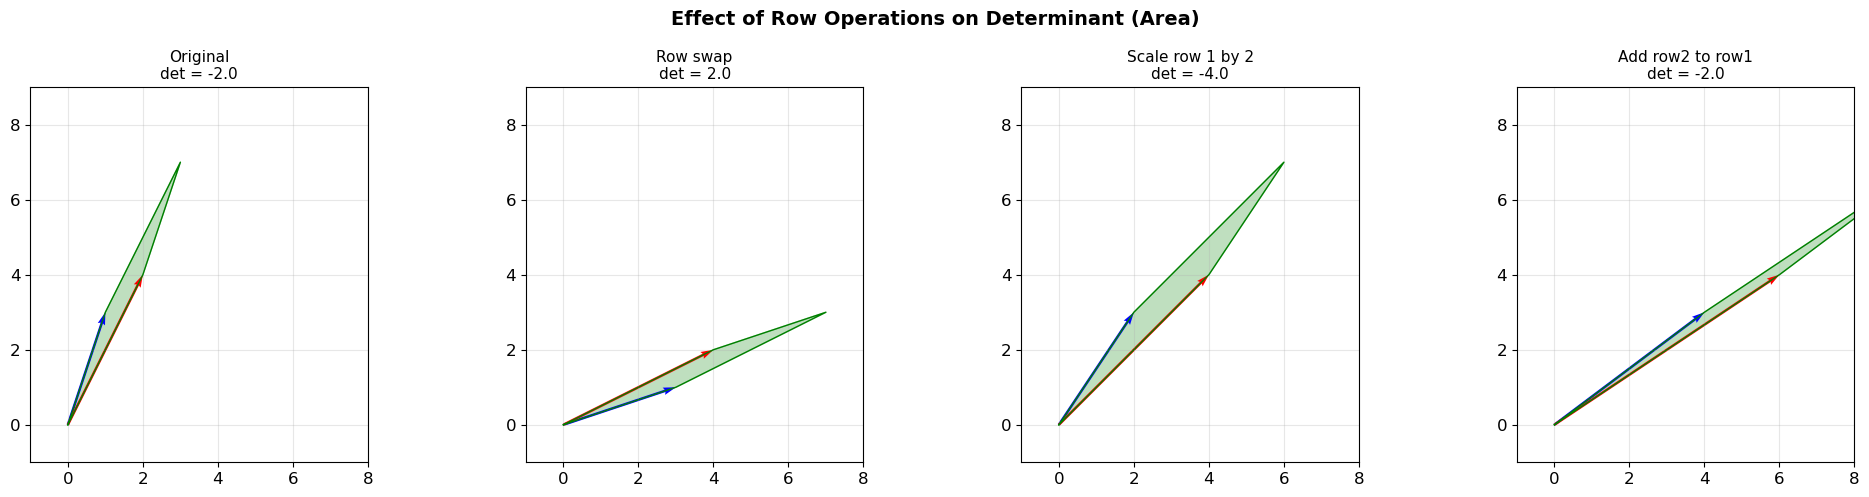

In [14]:
A_orig = np.array([[1, 2], [3, 4]])

operations = [
    ('Original', A_orig),
    ('Row swap', A_orig[[1, 0]]),
    ('Scale row 1 by 2', np.array([[2, 4], [3, 4]])),
    ('Add row2 to row1', np.array([[1+3, 2+4], [3, 4]])),
]

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, (name, M) in zip(axes, operations):
    v1, v2 = M[:, 0], M[:, 1]
    corners = np.array([[0,0], v1, v1+v2, v2, [0,0]])
    ax.fill(corners[:,0], corners[:,1], alpha=0.25, color='green')
    ax.plot(corners[:,0], corners[:,1], 'g-', linewidth=1)
    ax.quiver(0, 0, v1[0], v1[1], angles='xy', scale_units='xy', scale=1,
              color='blue', linewidth=2)
    ax.quiver(0, 0, v2[0], v2[1], angles='xy', scale_units='xy', scale=1,
              color='red', linewidth=2)
    det_val = np.linalg.det(M)
    ax.set_title(f'{name}\ndet = {det_val:.1f}', fontsize=11)
    ax.set_xlim(-1, 8)
    ax.set_ylim(-1, 9)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Effect of Row Operations on Determinant (Area)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

**Observations:**
- Row swap: area unchanged, sign flips ($-2 \to 2$)
- Scale row by 2: area doubles ($-2 \to -4$)
- Add multiple of one row to another: area unchanged ($-2 \to -2$) — this is a shear

## 7.4 Cramer's Rule

For an invertible system $A\mathbf{x} = \mathbf{b}$, each unknown $x_i$ is given by:

$$x_i = \frac{\det(A_i)}{\det(A)}$$

where $A_i$ is $A$ with its $i$-th column replaced by $\mathbf{b}$.

### 2D Example

In [15]:
def cramers_rule(A, b):
    """Solve Ax = b using Cramer's Rule."""
    n = len(b)
    det_A = np.linalg.det(A)
    if abs(det_A) < 1e-12:
        raise ValueError("det(A) = 0: system has no unique solution")
    
    x = np.zeros(n)
    for i in range(n):
        Ai = A.copy()
        Ai[:, i] = b
        x[i] = np.linalg.det(Ai) / det_A
    return x

# System: x1 + 2*x2 = 5,  3*x1 + 4*x2 = 11
A = np.array([[1, 2], [3, 4]], dtype=float)
b = np.array([5, 11], dtype=float)

x_cramer = cramers_rule(A, b)
x_direct = np.linalg.solve(A, b)

det_A = np.linalg.det(A)
A1 = A.copy(); A1[:, 0] = b
A2 = A.copy(); A2[:, 1] = b

print(f"det(A) = {det_A:.0f}")
print(f"det(A1) = {np.linalg.det(A1):.0f},  x1 = {np.linalg.det(A1):.0f}/{det_A:.0f} = {x_cramer[0]:.0f}")
print(f"det(A2) = {np.linalg.det(A2):.0f},  x2 = {np.linalg.det(A2):.0f}/{det_A:.0f} = {x_cramer[1]:.0f}")
print(f"\nCramer's rule:  x = {x_cramer}")
print(f"np.linalg.solve: x = {x_direct}")
print(f"Verify: A @ x = {A @ x_cramer}  (should be {b})")

det(A) = -2
det(A1) = -2,  x1 = -2/-2 = 1
det(A2) = -4,  x2 = -4/-2 = 2

Cramer's rule:  x = [1. 2.]
np.linalg.solve: x = [1. 2.]
Verify: A @ x = [ 5. 11.]  (should be [ 5. 11.])


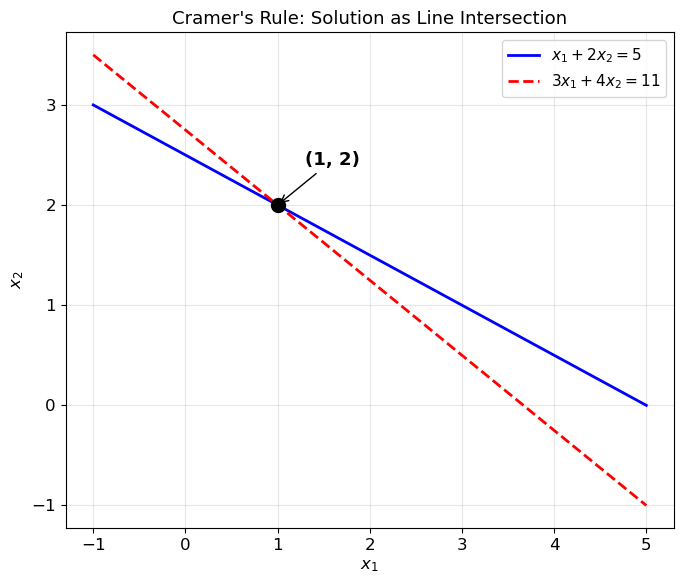

In [16]:
# Visualize Cramer's Rule solution as intersection
fig, ax = plt.subplots(figsize=(7, 6))
x1_r = np.linspace(-1, 5, 200)

ax.plot(x1_r, (5 - x1_r)/2, 'b-', linewidth=2, label=r'$x_1 + 2x_2 = 5$')
ax.plot(x1_r, (11 - 3*x1_r)/4, 'r--', linewidth=2, label=r'$3x_1 + 4x_2 = 11$')
ax.plot(x_cramer[0], x_cramer[1], 'ko', markersize=10)
ax.annotate(f'({x_cramer[0]:.0f}, {x_cramer[1]:.0f})',
            xy=x_cramer, xytext=(x_cramer[0]+0.3, x_cramer[1]+0.4),
            fontsize=13, fontweight='bold',
            arrowprops=dict(arrowstyle='->', color='black'))

ax.set_xlabel(r'$x_1$')
ax.set_ylabel(r'$x_2$')
ax.set_title("Cramer's Rule: Solution as Line Intersection", fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3D Example

In [17]:
# 3D Cramer's Rule
A3 = np.array([[ 3,  1, -2],
               [-1,  2,  3],
               [ 2,  1,  4]], dtype=float)
b3 = np.array([4, 1, -2], dtype=float)

x3 = cramers_rule(A3, b3)
print(f"det(A) = {np.linalg.det(A3):.0f}")
print(f"Solution: x = {x3}")
print(f"Verify: A @ x = {A3 @ x3}  (should be {b3})")

det(A) = 35
Solution: x = [ 0.  2. -1.]
Verify: A @ x = [ 4.  1. -2.]  (should be [ 4.  1. -2.])


## 7.5 Determinants in Machine Learning

### 7.5.1 Linear Regression: Invertibility of $X^TX$

The normal equations $\mathbf{w} = (X^TX)^{-1}X^T\mathbf{y}$ require $\det(X^TX) \neq 0$. A zero (or near-zero) determinant signals multicollinearity.

In [18]:
# Well-conditioned features
A_good = np.array([[1, 1],
                   [1, 2],
                   [1, 3]])
y = np.array([1, 2, 3])

XtX = A_good.T @ A_good
det_XtX = np.linalg.det(XtX)
print(f"X^T X =\n{XtX}")
print(f"det(X^T X) = {det_XtX:.0f}  (nonzero => regression is well-defined)")

w = np.linalg.solve(XtX, A_good.T @ y)
print(f"Weights: {w}")

# Multicollinear features
print("\n--- Multicollinear case ---")
A_bad = np.array([[1, 2],
                  [2, 4],
                  [3, 6]])  # col2 = 2*col1
XtX_bad = A_bad.T @ A_bad
print(f"det(X^T X) = {np.linalg.det(XtX_bad):.6f}  (zero => singular => cannot invert)")

X^T X =
[[ 3  6]
 [ 6 14]]
det(X^T X) = 6  (nonzero => regression is well-defined)
Weights: [0. 1.]

--- Multicollinear case ---
det(X^T X) = 0.000000  (zero => singular => cannot invert)


### 7.5.2 Covariance Matrix and Data Volume

The determinant of the covariance matrix measures the "volume" of the data's confidence ellipsoid. A larger determinant means the data is more spread out; a determinant near zero means the data is nearly confined to a lower-dimensional subspace.

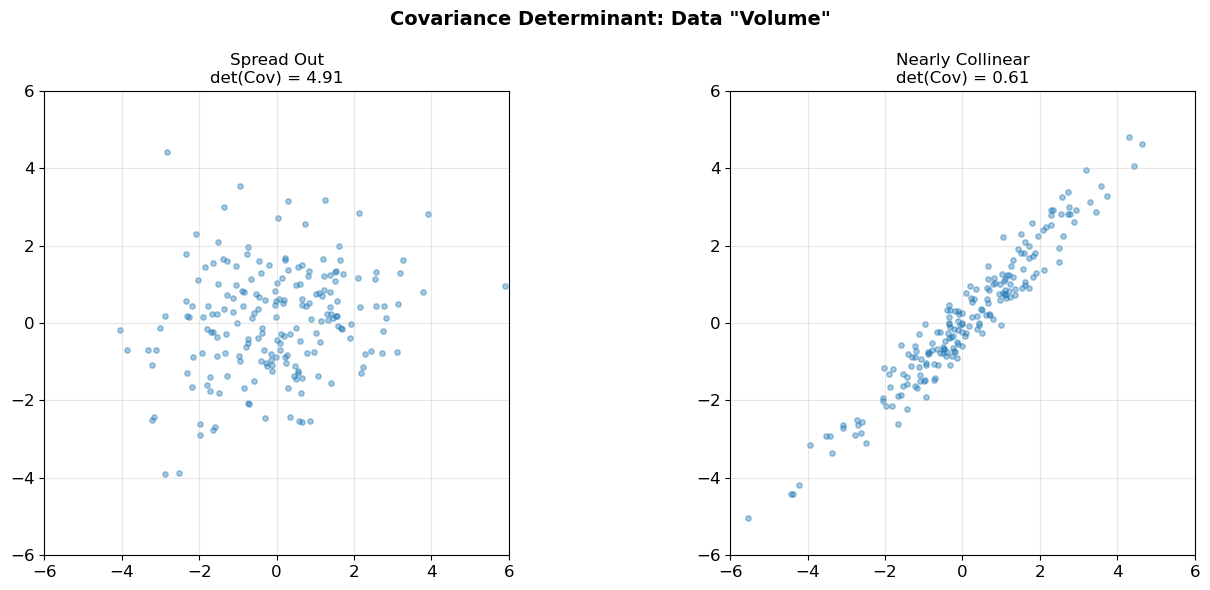

In [19]:
np.random.seed(42)

# Spread-out data (large det)
cov1 = np.array([[3, 0.5], [0.5, 2]])
data1 = np.random.multivariate_normal([0, 0], cov1, 200)

# Nearly collinear data (small det)
cov2 = np.array([[3, 2.9], [2.9, 3]])
data2 = np.random.multivariate_normal([0, 0], cov2, 200)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

for ax, data, cov_true, label in [(ax1, data1, cov1, 'Spread Out'),
                                    (ax2, data2, cov2, 'Nearly Collinear')]:
    cov_est = np.cov(data.T)
    det_val = np.linalg.det(cov_est)
    ax.scatter(data[:, 0], data[:, 1], alpha=0.4, s=15)
    ax.set_title(f'{label}\ndet(Cov) = {det_val:.2f}', fontsize=12)
    ax.set_xlim(-6, 6)
    ax.set_ylim(-6, 6)
    ax.set_aspect('equal')
    ax.grid(True, alpha=0.3)

plt.suptitle('Covariance Determinant: Data "Volume"', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.5.3 Normalizing Flows (Conceptual)

In generative models, normalizing flows use invertible transformations $\mathbf{x} = f(\mathbf{z})$ to map a simple distribution (e.g., Gaussian) to a complex one. The change-of-variables formula requires the **log-determinant of the Jacobian**:

$$\log p(\mathbf{x}) = \log p(\mathbf{z}) - \log |\det(J_f)|$$

This makes determinant computation a core operation in flow-based generative models.

In [20]:
# Simple affine flow: f(z) = Az + b
A_flow = np.array([[2.0, 0.5],
                   [0.3, 1.5]])

log_det_J = np.log(abs(np.linalg.det(A_flow)))
print(f"Flow matrix A =\n{A_flow}")
print(f"det(A) = {np.linalg.det(A_flow):.4f}")
print(f"log|det(A)| = {log_det_J:.4f}")
print(f"\nThis log-determinant adjusts the probability density under the transformation.")

Flow matrix A =
[[2.  0.5]
 [0.3 1.5]]
det(A) = 2.8500
log|det(A)| = 1.0473

This log-determinant adjusts the probability density under the transformation.


### ML Applications Summary

| Application | Role of Determinant |
|-------------|--------------------|
| Linear Regression | $\det(X^TX) \neq 0$ ensures unique solution |
| PCA | det(Cov) measures data spread / ellipsoid volume |
| Normalizing Flows | $\log|\det(J)|$ adjusts density under transformation |
| Gaussian Processes | Log-det in marginal likelihood for hyperparameter tuning |
| Optimization | Hessian determinant indicates curvature (saddle vs. min/max) |

## 7.6 Exercises

Selected exercises from the chapter.

**Exercise 1:** Compute $\det\begin{bmatrix} 4 & 3 \\ 1 & 2 \end{bmatrix}$.

In [21]:
# Exercise 1: Your code here


**Exercise 3:** Solve $3x_1 + x_2 = 5$, $x_1 + 2x_2 = 4$ using Cramer's rule.

In [22]:
# Exercise 3: Your code here


**Exercise 4:** Verify $\det(AB) = \det(A)\det(B)$ for $A = \begin{bmatrix} 2 & 1 \\ 1 & 3 \end{bmatrix}$, $B = \begin{bmatrix} 1 & 0 \\ 0 & 2 \end{bmatrix}$.

In [23]:
# Exercise 4: Your code here


**Exercise 5:** For $A = \text{diag}(5, 2, 1)$, compute $\det(A)$, $\det(3A)$, and verify $\det(3A) = 3^3 \det(A)$.

In [24]:
# Exercise 5: Your code here


**Exercise 18:** Visualize the area of the parallelogram formed by columns of $A = \begin{bmatrix} 2 & 1 \\ 1 & 3 \end{bmatrix}$.

In [25]:
# Exercise 18: Your code here


---

## Exercise Solutions

In [26]:
# --- Solution: Exercise 1 ---
M = np.array([[4, 3], [1, 2]])
print(f"det = {4*2 - 3*1} = {np.linalg.det(M):.0f}")

det = 5 = 5


In [27]:
# --- Solution: Exercise 3 ---
A = np.array([[3, 1], [1, 2]], dtype=float)
b = np.array([5, 4], dtype=float)
x = cramers_rule(A, b)
print(f"Cramer's rule: x = {x}")
print(f"Verify: A @ x = {A @ x}")

Cramer's rule: x = [1.2 1.4]
Verify: A @ x = [5. 4.]


In [28]:
# --- Solution: Exercise 4 ---
A = np.array([[2, 1], [1, 3]])
B = np.array([[1, 0], [0, 2]])
print(f"det(A) = {np.linalg.det(A):.0f}")
print(f"det(B) = {np.linalg.det(B):.0f}")
print(f"det(AB) = {np.linalg.det(A @ B):.0f}")
print(f"det(A)*det(B) = {np.linalg.det(A)*np.linalg.det(B):.0f}")
print(f"Equal: {np.isclose(np.linalg.det(A@B), np.linalg.det(A)*np.linalg.det(B))}")

det(A) = 5
det(B) = 2
det(AB) = 10
det(A)*det(B) = 10
Equal: True


In [29]:
# --- Solution: Exercise 5 ---
A = np.diag([5, 2, 1])
k = 3
print(f"det(A) = {np.linalg.det(A):.0f}")
print(f"det(3A) = {np.linalg.det(k*A):.0f}")
print(f"3^3 * det(A) = {k**3 * np.linalg.det(A):.0f}")
print(f"Equal: {np.isclose(np.linalg.det(k*A), k**3 * np.linalg.det(A))}")

det(A) = 10
det(3A) = 270
3^3 * det(A) = 270
Equal: True


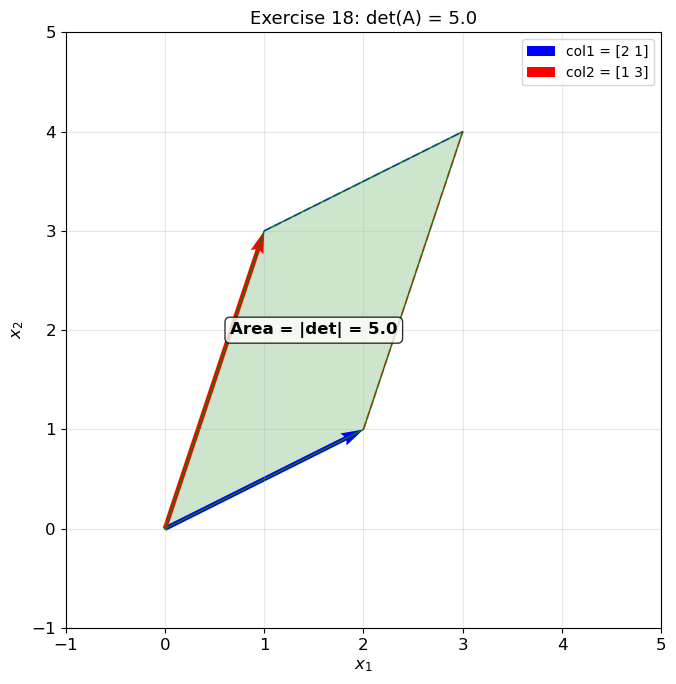

In [30]:
# --- Solution: Exercise 18 ---
plot_parallelogram(np.array([[2, 1], [1, 3]]), 'Exercise 18: ')